In [1]:
import pandas as pd
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


In [2]:

# --------------------------------------------------
# Canonical model config
# --------------------------------------------------
MODEL_ORDER = ['svm', 'dnn', 'rf', 'mf','sage', 'gcn']
MODEL_NAME_MAP = {
    'svm': 'SVM',
    'dnn': 'DNN',
    'rf': 'RF',
    'mf':'MF',
    'sage': 'GraphSage',
    'gcn': 'GCN'
}

# --------------------------------------------------
# Feature config
# NOTE:
# - FEATURE_NAME_MAP maps raw feature keys -> display names
# - FEATURE_ORDER is now the DISPLAY order
# --------------------------------------------------
FEATURE_NAME_MAP = {
    "ppi_emb_df": "PPI-df",
    "ppi_emb_dw": "PPI-dw",
    "ppi_emb_n2v": "PPI-n2v",
    "literature_emb": "Literature",
    "seq_emb_esm": "Seq-esm",
    "seq_emb_port": "Seq-port",
}

FEATURE_ORDER = ["PPI-df", "PPI-dw", "PPI-n2v", "Literature", "Seq-esm", "Seq-port"]

# reverse map: display name -> raw key
FEATURE_NAME_MAP_REV = {v: k for k, v in FEATURE_NAME_MAP.items()}


# --------------------------------------------------
# Map raw input key to canonical raw feature key
# --------------------------------------------------
def map_feature(key):
    key = key.lower()

    if 'dw' in key:
        return 'ppi_emb_dw'
    elif 'df' in key:
        return 'ppi_emb_df'
    elif 'n2v' in key:
        return 'ppi_emb_n2v'
    elif 'lit' in key:
        return 'literature_emb'
    elif 'esm' in key:
        return 'seq_emb_esm'
    elif 'seq' in key:
        return 'seq_emb_port'

    elif 'diffusion' in key:
        return 'ppi_emb_df'
    elif 'uniport_ppi_2019' in key:
        return 'ppi_emb_n2v'
    elif 'bio' in key:
        return 'literature_emb'

    else:
        return key


def detect_model(key):
    key = key.lower()
    for m in MODEL_ORDER:
        if m in key:
            return m
    return None


def jaccard(set_a, set_b):
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if len(union) > 0 else 0.0


def count_overlap(set_a, set_b):
    return len(set_a & set_b)


def build_similarity_matrices(group_dict, order, label_map=None, reverse_map=None):
    """
    group_dict: {raw_key: set_of_genes}
    order: plotting order
        - if reverse_map is provided, order is assumed to be DISPLAY names
        - otherwise order is assumed to be raw keys
    label_map: raw_key -> display_name
    reverse_map: display_name -> raw_key
    """
    if reverse_map is not None:
        ordered_raw = [
            reverse_map[display_name]
            for display_name in order
            if display_name in reverse_map and reverse_map[display_name] in group_dict
        ]
        labels = [
            display_name
            for display_name in order
            if display_name in reverse_map and reverse_map[display_name] in group_dict
        ]
    else:
        ordered_raw = [x for x in order if x in group_dict]
        if label_map is None:
            labels = ordered_raw
        else:
            labels = [label_map.get(x, x) for x in ordered_raw]

    n = len(ordered_raw)
    if n == 0:
        return None, None, None, None

    jaccard_matrix = np.zeros((n, n))
    overlap_matrix = np.zeros((n, n), dtype=int)

    for i, a in enumerate(ordered_raw):
        for j, b in enumerate(ordered_raw):
            set_a = set(group_dict[a])
            set_b = set(group_dict[b])
            jaccard_matrix[i, j] = jaccard(set_a, set_b)
            overlap_matrix[i, j] = count_overlap(set_a, set_b)

    df_jaccard = pd.DataFrame(jaccard_matrix, index=labels, columns=labels)
    df_overlap = pd.DataFrame(overlap_matrix, index=labels, columns=labels)

    annot = df_overlap.astype(str) + "\n(" + df_jaccard.round(2).astype(str) + ")"

    return df_jaccard, df_overlap, annot, ordered_raw


def plot_heatmap_on_ax(ax, df_jaccard, annot, title):
    hm = sns.heatmap(
        df_jaccard,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 8},
        ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    return hm


def make_big_figure(n_panels, ncols=3, figsize_per_panel=(5.2, 4.6)):
    nrows = math.ceil(n_panels / ncols)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False
    )
    return fig, axes


def organize_top_collection(top_collection):
    """
    Returns nested dict:
        organized[model][raw_feature_key] = set_of_genes
    """
    organized = {m: {} for m in MODEL_ORDER}

    for key, value in top_collection.items():
        model = detect_model(key)
        feature_raw = map_feature(key)

        if model is None:
            continue
        if feature_raw not in FEATURE_NAME_MAP:
            continue

        organized[model][feature_raw] = set(value)

    return organized


# --------------------------------------------------
# Big plot 1: feature-vs-feature within each model
# --------------------------------------------------
def plot_features_per_model(top_collection):
    organized = organize_top_collection(top_collection)

    models_to_plot = [m for m in MODEL_ORDER if len(organized[m]) > 0]
    fig, axes = make_big_figure(len(models_to_plot), ncols=3)
    axes_flat = axes.flatten()

    heatmap_mappable = None

    for i, model in enumerate(models_to_plot):
        ax = axes_flat[i]

        df_jaccard, df_overlap, annot, _ = build_similarity_matrices(
            organized[model],
            order=FEATURE_ORDER,                  # display order
            label_map=FEATURE_NAME_MAP,
            reverse_map=FEATURE_NAME_MAP_REV      # display -> raw
        )

        if df_jaccard is None:
            ax.axis("off")
            continue

        hm = plot_heatmap_on_ax(
            ax=ax,
            df_jaccard=df_jaccard,
            annot=annot,
            title=MODEL_NAME_MAP.get(model, model)
        )
        heatmap_mappable = hm.collections[0]

    for j in range(len(models_to_plot), len(axes_flat)):
        axes_flat[j].axis("off")

    if heatmap_mappable is None:
        sm = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap="Blues")
        sm.set_array([])
        heatmap_mappable = sm

    fig.subplots_adjust(right=0.90, wspace=0.35, hspace=0.45)
    cbar_ax = fig.add_axes([0.92, 0.35, 0.008, 0.3])
    cbar = fig.colorbar(heatmap_mappable, cax=cbar_ax)
    cbar.set_label("Jaccard Similarity")

    fig.suptitle("Top Gene Similarity: Between Features per Model", fontsize=16, y=0.98)
    return fig


# --------------------------------------------------
# Big plot 2: model-vs-model within each feature
# --------------------------------------------------
def plot_models_per_feature(top_collection):
    organized = organize_top_collection(top_collection)

    # use RAW feature keys here internally
    by_feature = {raw_feature: {} for raw_feature in FEATURE_NAME_MAP.keys()}

    for model in MODEL_ORDER:
        for feature_raw, gene_set in organized[model].items():
            by_feature[feature_raw][model] = gene_set

    # choose feature plotting order based on DISPLAY order,
    # but convert back to RAW keys for accessing data
    features_to_plot = [
        FEATURE_NAME_MAP_REV[display_name]
        for display_name in FEATURE_ORDER
        if FEATURE_NAME_MAP_REV[display_name] in by_feature
        and len(by_feature[FEATURE_NAME_MAP_REV[display_name]]) > 0
    ]

    fig, axes = make_big_figure(len(features_to_plot), ncols=3)
    axes_flat = axes.flatten()

    heatmap_mappable = None

    for i, feature_raw in enumerate(features_to_plot):
        ax = axes_flat[i]

        df_jaccard, df_overlap, annot, _ = build_similarity_matrices(
            by_feature[feature_raw],
            order=MODEL_ORDER,
            label_map=MODEL_NAME_MAP,
            reverse_map=None
        )

        if df_jaccard is None:
            ax.axis("off")
            continue

        hm = plot_heatmap_on_ax(
            ax=ax,
            df_jaccard=df_jaccard,
            annot=annot,
            title=FEATURE_NAME_MAP.get(feature_raw, feature_raw)
        )
        heatmap_mappable = hm.collections[0]

    for j in range(len(features_to_plot), len(axes_flat)):
        axes_flat[j].axis("off")

    if heatmap_mappable is None:
        sm = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap="Blues")
        sm.set_array([])
        heatmap_mappable = sm

    fig.subplots_adjust(right=0.90, wspace=0.35, hspace=0.45)
    cbar_ax = fig.add_axes([0.92, 0.35, 0.008, 0.3])
    cbar = fig.colorbar(heatmap_mappable, cax=cbar_ax)
    cbar.set_label("Jaccard Similarity")

    fig.suptitle("Top Gene Similarity: Between Models per Feature", fontsize=16, y=0.98)
    return fig


# --------------------------------------------------
# Main wrapper
# --------------------------------------------------
def plot_all_top_gene_similarity(top_collection):
    """
    Returns:
        fig1: big plot for feature-vs-feature within each model
        fig2: big plot for model-vs-model within each feature
    """
    fig1 = plot_features_per_model(top_collection)
    fig2 = plot_models_per_feature(top_collection)
    plt.show()
    return fig1, fig2

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- load and build top_collection ----
def temp_plot(path):
    with open(path, "rb") as f:
        data = pickle.load(f)

    top_collection = {}
    k = 300

    for feature in list(data.keys()):
        if feature not in ['true_label', 'test_genes', 'train_pos_genes']:
            if feature.startswith('gcn'):
                indices = np.argpartition(data[feature], -k)[-k:]
                indices = indices[np.argsort(data[feature][indices])[::-1]]
                top_collection[feature] = set(data['test_genes'][indices])

    # ---- jaccard similarity ----
    # ---- jaccard similarity ----
    features = list(top_collection.keys())
    priority = ['gcn_diffusion_2019_pca']

    features = priority + [f for f in features if f not in priority]

    n = len(features)
    jaccard_mat = np.zeros((n, n))

    for i, fi in enumerate(features):
        set_i = top_collection[fi]
        for j, fj in enumerate(features):
            set_j = top_collection[fj]
            union = set_i | set_j
            inter = set_i & set_j
            jaccard_mat[i, j] = len(inter) / len(union) if len(union) > 0 else 0.0

    jaccard_df = pd.DataFrame(jaccard_mat, index=features, columns=features)

    # ---- plot heatmap ----
    fig, ax = plt.subplots(figsize=(4, 4))

    im = ax.imshow(
        jaccard_df.values,
        aspect='auto',
        vmin=0,   # force lower bound
        vmax=1    # force upper bound
    )

    ax.set_xticks(np.arange(len(jaccard_df.columns)))
    ax.set_yticks(np.arange(len(jaccard_df.index)))
    ax.set_xticklabels(jaccard_df.columns, rotation=90)
    ax.set_yticklabels(jaccard_df.index)

    ax.set_title(f'Jaccard similarity heatmap (top {k} genes per feature)')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Jaccard similarity')

    plt.tight_layout()
    plt.show()

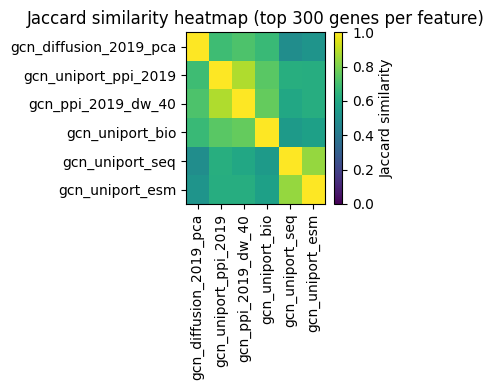

In [7]:
# path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gcn_deoversmooth_pred/ICD10_C16_pred.pkl'
path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gnn_add_pred/ICD10_C16_pred.pkl'
temp_plot(path)

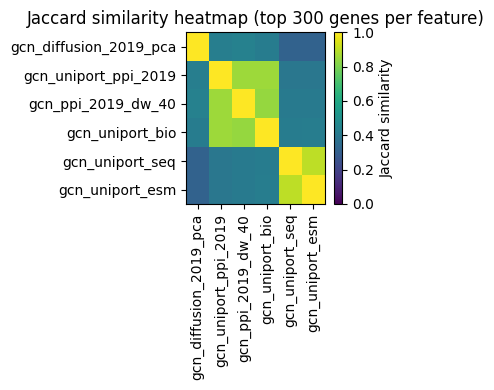

In [3]:
path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gcn_deoversmooth_pred/ICD10_C16_pred.pkl'
# path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gnn_add_pred/ICD10_C16_pred.pkl'
temp_plot(path)

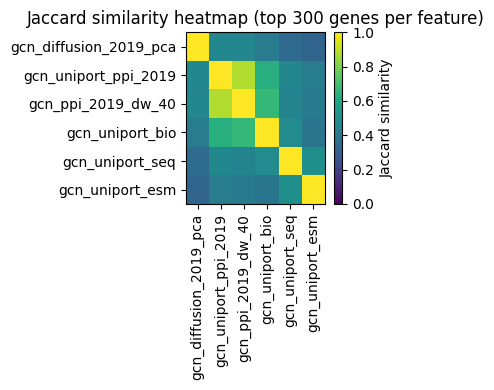

In [4]:
path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gcn_deoversmooth_less_smooth_pred/ICD10_I70_pred.pkl'
temp_plot(path)
# path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gcn_deoversmooth_pred/ICD10_C16_pred.pkl'
# path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_gnn_add_pred/ICD10_C16_pred.pkl'

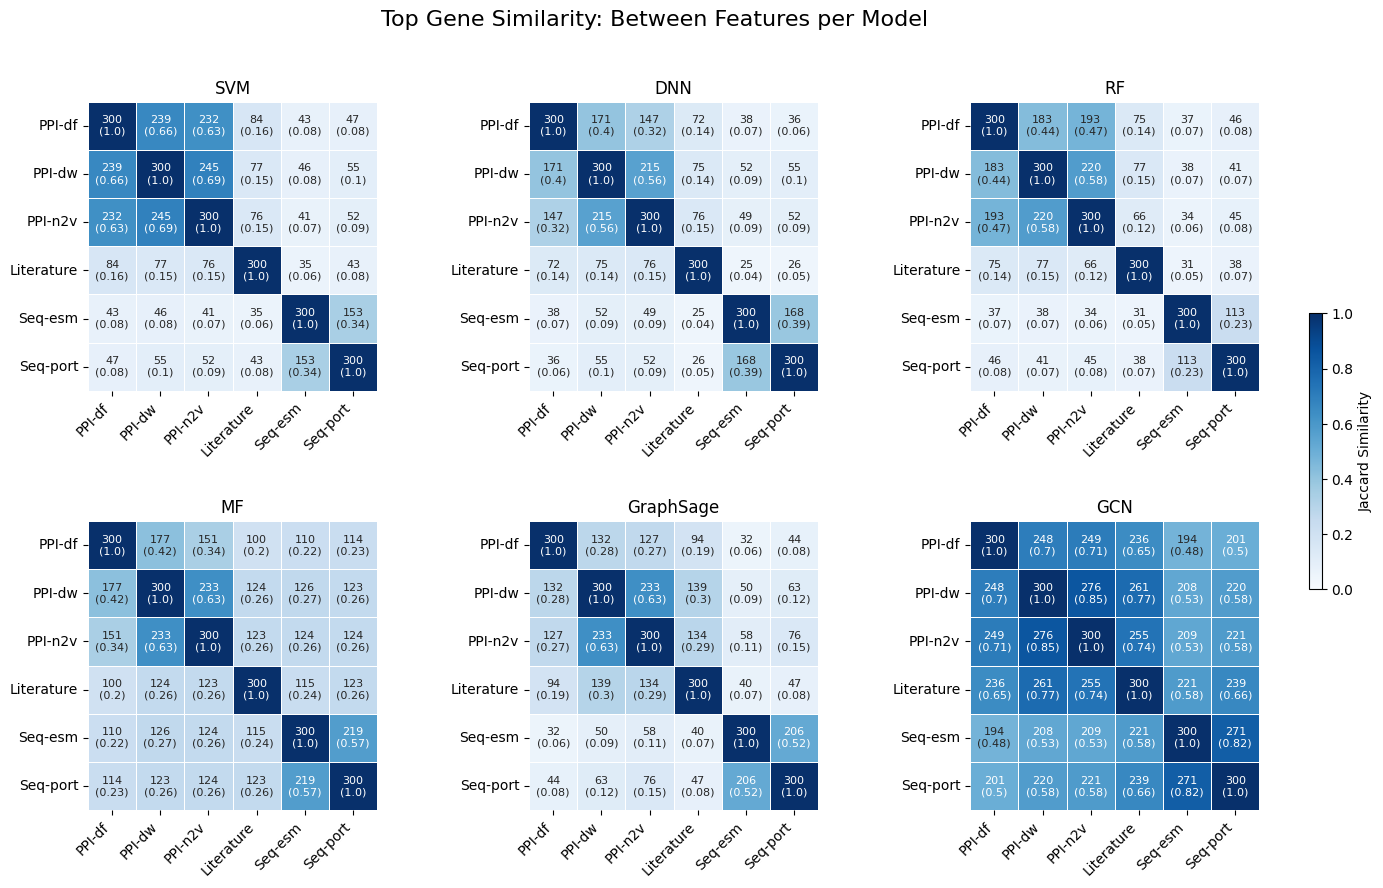

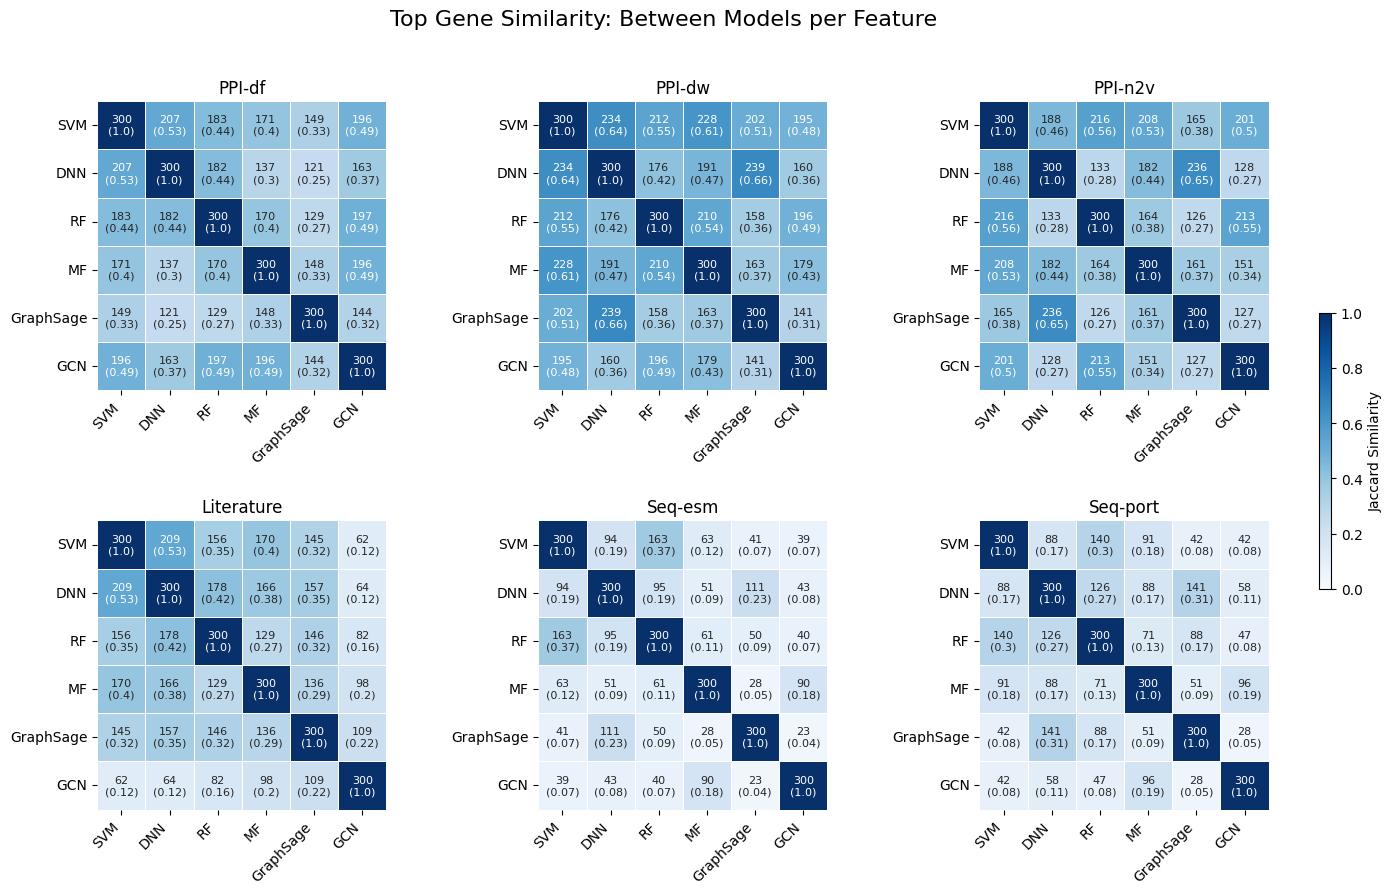

In [7]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/'
paths = ['df_gnn_occsvm_pred','2019_nn_all_pred','2019_rf_renamed_pred','2019_mf_add_pred','2019_gnn_add_pred']
name_map = ['svm','dnn','rf','mf','gnn']
# paths = ['df_gnn_occsvm_pred','2019_nn_all_pred','2019_rf_renamed_pred','2019_gnn_add_pred']
# name_map = ['svm','dnn','rf','gnn']
# paths = ['2019_gnn_add_pred']
# name_map = ['gnn']

# paths = ['2019_mf_add_pred']
# name_map = ['mf']
features = ['ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']

top_collection = dict()
k = 300

disease = 'ICD10_I70'
filename = disease +'_pred.pkl'
for name_id, path in enumerate(paths):
    with open(os.path.join(root, path,filename), "rb") as f:
        data = pickle.load(f)
    if name_map[name_id] == 'gnn': 
        for feature in list(data.keys()):
            if 'gcn' in feature or 'sage' in feature:
                indices = np.argpartition(data[feature], -k)[-k:]
                indices = indices[np.argsort(data[feature][indices])[::-1]]
                top_collection[feature] = set(data['test_genes'][indices])  
    elif name_map[name_id] == 'mf': 
        for feature in list(data.keys()):
            if feature not in ['true_label', 'test_genes', 'train_pos_genes']:
                indices = np.argpartition(data[feature], -k)[-k:]
                indices = indices[np.argsort(data[feature][indices])[::-1]]
                top_collection[name_map[name_id]+'_'+feature] = set(data['test_genes'][indices]) 
    else:
        for feature in list(data.keys()):
            if any(word in feature for word in features):
                indices = np.argpartition(data[feature], -k)[-k:]
                indices = indices[np.argsort(data[feature][indices])[::-1]]
                top_collection[name_map[name_id]+'_'+feature] = set(data['test_genes'][indices])

fig_features_per_model, fig_models_per_feature = plot_all_top_gene_similarity(top_collection)

In [3]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/'

paths = ['df_gnn_occsvm_pred','2019_nn_all_pred']
name_map = ['svm','dnn']

top_collection = dict()
k = 300
disease = 'ICD10_I70'
filename = disease +'_pred.pkl'
for name_id, path in enumerate(paths):
    with open(os.path.join(root, path,filename), "rb") as f:
        data = pickle.load(f)
    if name_map[name_id] == 'svm':
        selected_features = ['early_fused', 'late_fused','mid_linear_fused','mid_geo_fused','early_fused_ppi', 'late_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi']
    if name_map[name_id] == 'dnn':
        selected_features = ['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi']

    for feature in selected_features:
        indices = np.argpartition(data[feature], -k)[-k:]
        indices = indices[np.argsort(data[feature][indices])[::-1]]
        top_collection[name_map[name_id]+'_'+feature] = set(data['test_genes'][indices])



/tmp/ipykernel_2162980/1891010337.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 0.95])


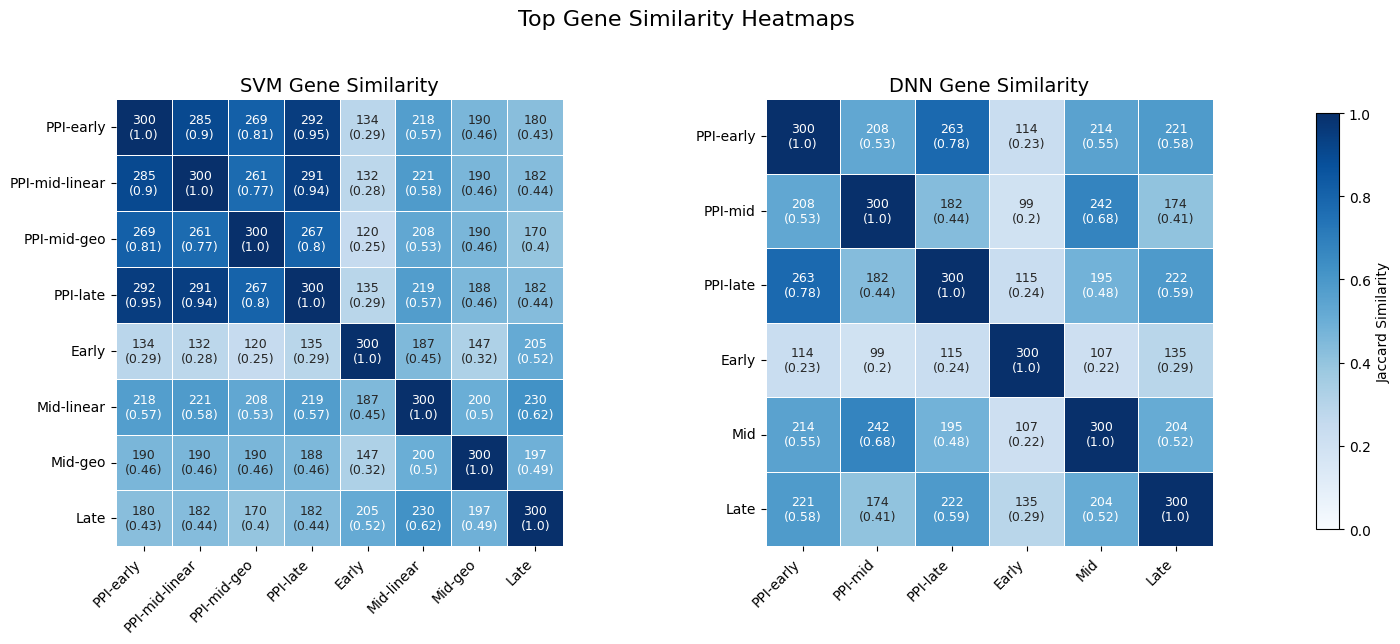

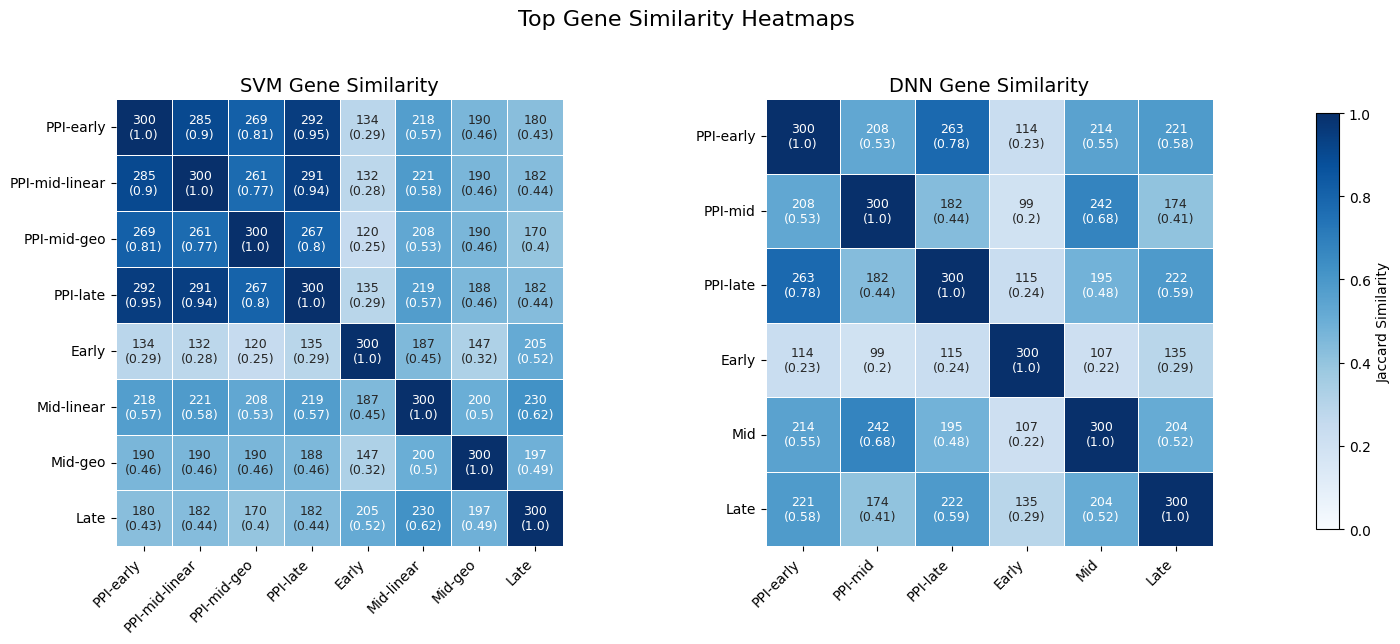

In [5]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_gene_similarity_svm_dnn(top_collection):
    """
    Plot two gene similarity heatmaps from top_collection:
      1) SVM heatmap (8 features)
      2) DNN heatmap (6 features)

    Cell annotation:
      overlap_count
      (jaccard)

    Feature order rule:
      - PPI features first
      - then non-PPI features
      - within each group: early -> mid -> late
      - within "mid": linear -> geo for SVM
    """

    # -----------------------------
    # fixed feature order
    # -----------------------------
    svm_feature_order = [
        "early_fused_ppi",
        "mid_linear_fused_ppi",
        "mid_geo_fused_ppi",
        "late_fused_ppi",
        "early_fused",
        "mid_linear_fused",
        "mid_geo_fused",
        "late_fused",
    ]

    dnn_feature_order = [
        "early_fused_ppi",
        "mid_fused_ppi",
        "late_fused_ppi",
        "early_fused",
        "mid_fused",
        "late_fused",
    ]

    # display names
    feature_display_map = {
        "early_fused_ppi": "PPI-early",
        "mid_linear_fused_ppi": "PPI-mid-linear",
        "mid_geo_fused_ppi": "PPI-mid-geo",
        "late_fused_ppi": "PPI-late",
        "early_fused": "Early",
        "mid_linear_fused": "Mid-linear",
        "mid_geo_fused": "Mid-geo",
        "late_fused": "Late",
        "mid_fused_ppi": "PPI-mid",
        "mid_fused": "Mid",
    }

    # -----------------------------
    # helpers
    # -----------------------------
    def jaccard(set_a, set_b):
        union = set_a | set_b
        return len(set_a & set_b) / len(union) if len(union) > 0 else 0.0

    def overlap_count(set_a, set_b):
        return len(set_a & set_b)

    def extract_model_features(model_prefix, feature_order):
        """
        Build ordered dict-like mapping:
        {feature_name: set_of_genes}
        """
        out = {}
        for feat in feature_order:
            key = f"{model_prefix}_{feat}"
            if key in top_collection:
                out[feat] = set(top_collection[key])
        return out

    def build_similarity_df(feature_sets, feature_order):
        available = [f for f in feature_order if f in feature_sets]
        n = len(available)

        if n == 0:
            return None, None, None

        jaccard_matrix = np.zeros((n, n))
        overlap_matrix = np.zeros((n, n), dtype=int)

        for i, fi in enumerate(available):
            for j, fj in enumerate(available):
                set_i = feature_sets[fi]
                set_j = feature_sets[fj]
                jaccard_matrix[i, j] = jaccard(set_i, set_j)
                overlap_matrix[i, j] = overlap_count(set_i, set_j)

        labels = [feature_display_map.get(f, f) for f in available]

        df_jaccard = pd.DataFrame(jaccard_matrix, index=labels, columns=labels)
        df_overlap = pd.DataFrame(overlap_matrix, index=labels, columns=labels)
        annot = df_overlap.astype(str) + "\n(" + df_jaccard.round(2).astype(str) + ")"

        return df_jaccard, df_overlap, annot

    def plot_single_heatmap(ax, df_jaccard, annot, title):
        sns.heatmap(
            df_jaccard,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            square=True,
            cbar=False,
            linewidths=0.5,
            linecolor="white",
            annot_kws={"size": 9},
            ax=ax,
        )
        ax.set_title(title, fontsize=14)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # -----------------------------
    # prepare data
    # -----------------------------
    svm_sets = extract_model_features("svm", svm_feature_order)
    dnn_sets = extract_model_features("dnn", dnn_feature_order)

    svm_jac, svm_ov, svm_annot = build_similarity_df(svm_sets, svm_feature_order)
    dnn_jac, dnn_ov, dnn_annot = build_similarity_df(dnn_sets, dnn_feature_order)

    # -----------------------------
    # plot
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    if svm_jac is not None:
        plot_single_heatmap(axes[0], svm_jac, svm_annot, "SVM Gene Similarity")
    else:
        axes[0].axis("off")
        axes[0].set_title("SVM Gene Similarity (no data)")

    if dnn_jac is not None:
        plot_single_heatmap(axes[1], dnn_jac, dnn_annot, "DNN Gene Similarity")
    else:
        axes[1].axis("off")
        axes[1].set_title("DNN Gene Similarity (no data)")

    # shared colorbar
    norm = plt.Normalize(vmin=0, vmax=1)
    sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
    sm.set_array([])

    fig.subplots_adjust(right=0.90, wspace=0.35)
    cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.64])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Jaccard Similarity")

    fig.suptitle("Top Gene Similarity Heatmaps", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 0.90, 0.95])
    plt.show()

    return fig


# --------------------------------------------------
# Example usage with your existing top_collection
# --------------------------------------------------
plot_gene_similarity_svm_dnn(top_collection)